# 1. Data Import & Overview
Trong phần này, chúng ta sẽ import các thư viện cần thiết và load tập dữ liệu.


In [14]:
import pandas
print(pandas.__file__)

c:\Users\Bui Trong Nguyen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\__init__.py


In [15]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../data/bank-full.csv')

In [17]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [18]:
df.shape

(45211, 17)

# 2. Exploratory Data Analysis (EDA)
Khám phá dữ liệu để hiểu rõ về các cột, phân phối và giá trị khuyết thiếu.


### 2.1. Thông tin chung về dữ liệu
Kiểm tra kiểu dữ liệu của từng cột và các giá trị null cơ bản.


In [19]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [21]:
df.isna().mean()

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64

<Axes: >

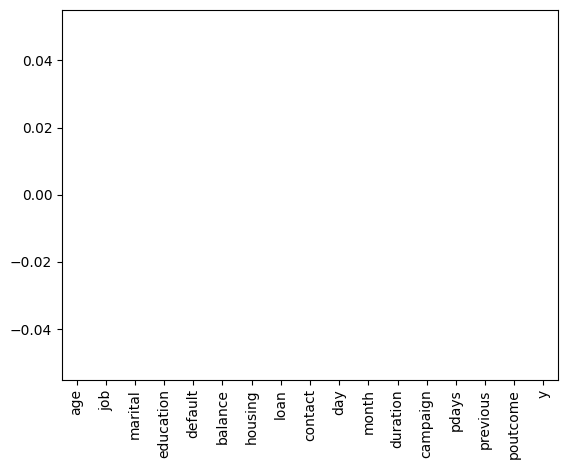

In [22]:
(df.isna().sum()/df.shape[0]).sort_values().plot(kind='bar')

### 2.2. Thống kê mô tả
Xem qua các chỉ số thống kê cơ bản (mean, min, max...) của các cột dạng số.


In [23]:
# df.describe()
df_num = df.describe().round(2)
df_num

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [24]:
df_cat = df.describe(include=['object'])
df_cat

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


### 2.3. Phân tích biến mục tiêu (Target Variable)
**Nhiệm vụ:** Vẽ biểu đồ đếm (countplot) cho cột `y` để xem tỷ lệ imbalanced.

In [25]:
df['y'].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

### 2.4. Phân tích, kiểm tra từng đặc trưng


#### Categorical

In [26]:
(df['job'].value_counts(normalize=True)).to_frame()

,proportion
job,
blue-collar,0.215257
management,0.209197
technician,0.168034
admin.,0.114375
services,0.091880
retired,0.050076
self-employed,0.034925
entrepreneur,0.032890
unemployed,0.028820


In [27]:
df['marital'].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [28]:
df['month'].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

#### Numerical

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'duration'}>]], dtype=object)

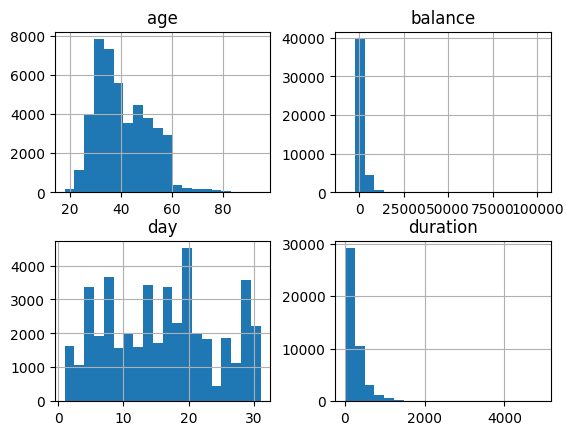

In [29]:
df.iloc[:,0:12].hist(bins=20)

array([[<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>]], dtype=object)

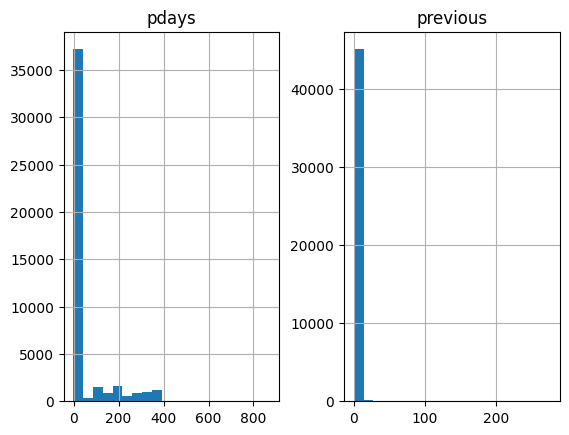

In [30]:
df.iloc[:,13:18].hist(bins=20)

<Axes: >

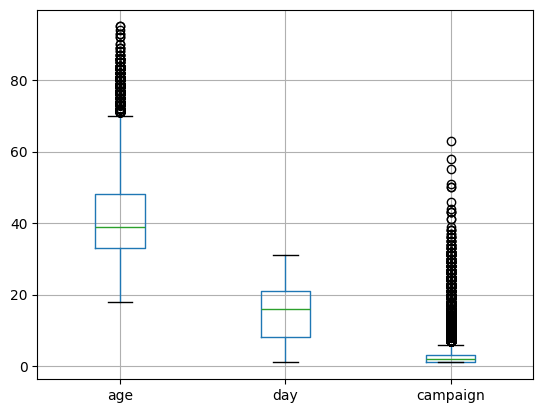

In [31]:
df[['age','day', 'campaign']].boxplot()

<Axes: >

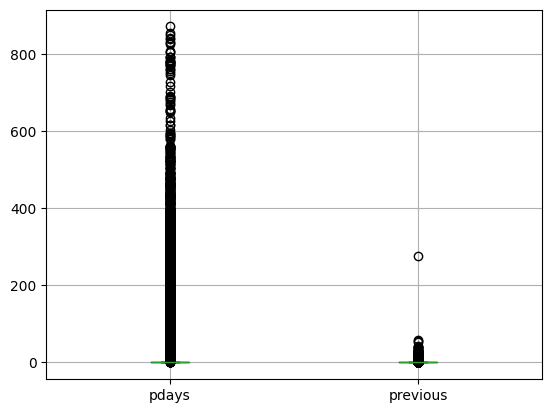

In [32]:
df[['pdays', 'previous']].boxplot()

<Axes: >

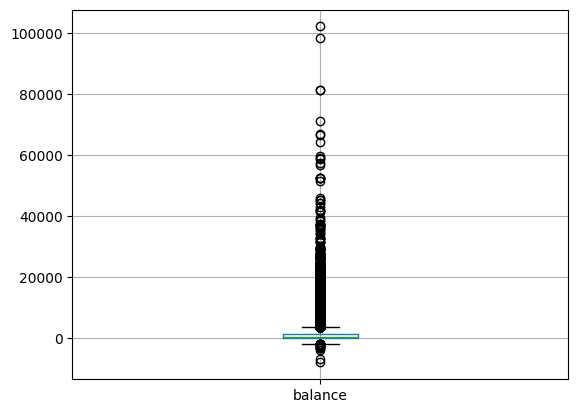

In [33]:
df[['balance']].boxplot()

<Axes: >

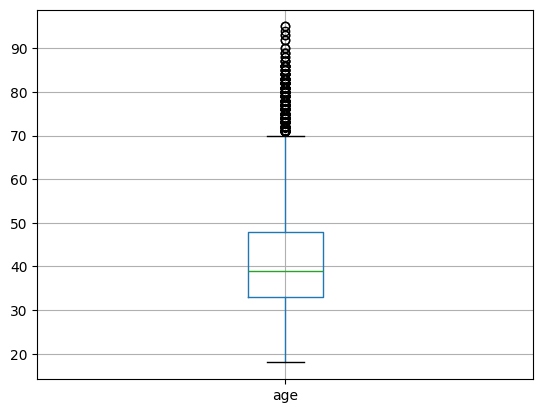

In [34]:
df[['age']].boxplot()

### 2.5. Phân tích hai biến và đa biến (Bivariate & Multivariate Analysis)
Khám phá mối quan hệ giữa các biến đặc trưng và biến mục tiêu `y`.

#### Mối quan hệ giữa các biến phân loại và biến mục tiêu

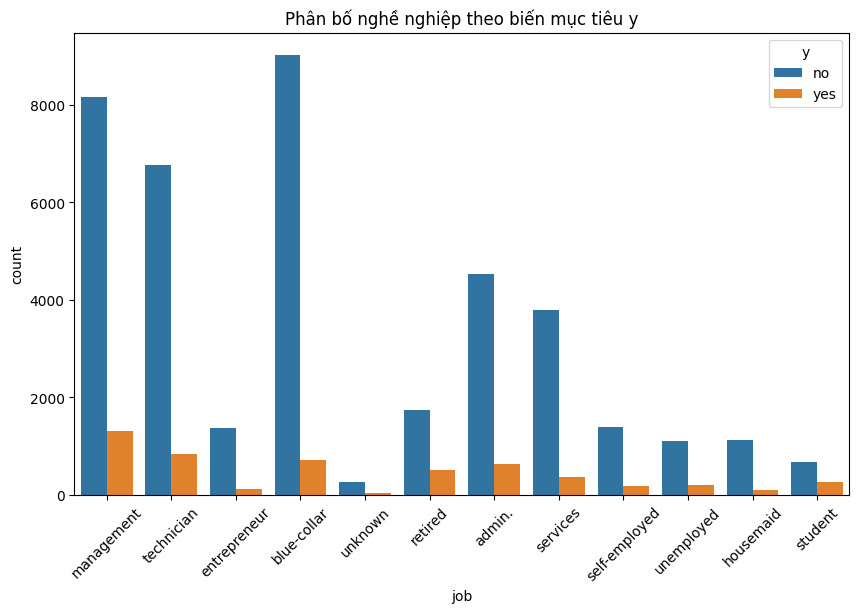

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(x='job', hue='y', data=df)
plt.title('Phân bố nghề nghiệp theo biến mục tiêu y')
plt.xticks(rotation=45)
plt.show()

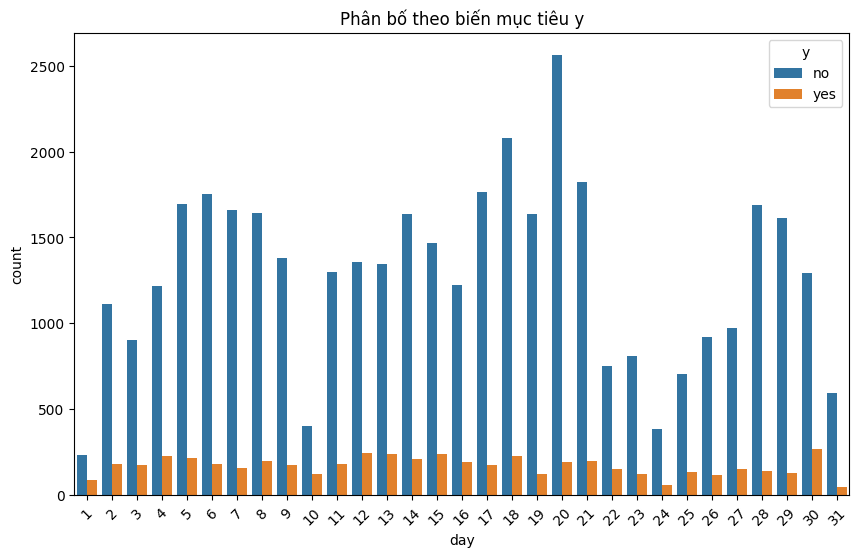

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(x='day', hue='y', data=df)
plt.title('Phân bố theo biến mục tiêu y')
plt.xticks(rotation=45)
plt.show()

#### Mối quan hệ giữa các biến số và biến mục tiêu

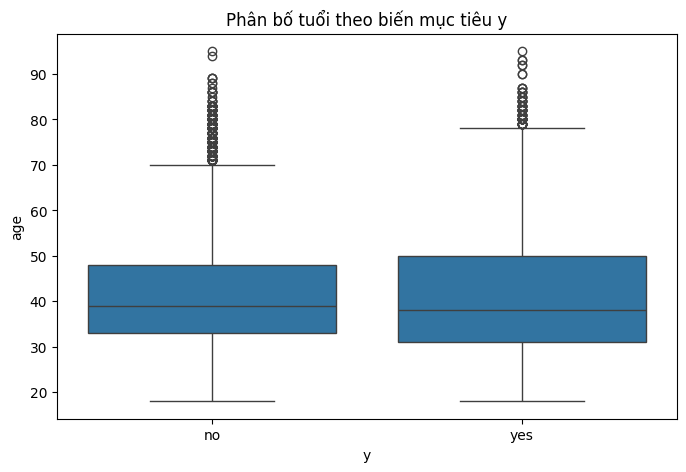

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='age', data=df)
plt.title('Phân bố tuổi theo biến mục tiêu y')
plt.show()

### 2.6. Phân tích tương quan (Correlation Analysis)
Kiểm tra mức độ tương quan tuyến tính giữa các biến số.

In [38]:
df.corr(numeric_only=True)
# df.corr() chỉ dùng cho đặc trưng số

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


In [39]:
df.corr(numeric_only=True, method='spearman')

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.096380,-0.008948,-0.033257,0.037136,-0.017468,-0.011900
balance,0.096380,1.000000,0.001329,0.042651,-0.030959,0.069676,0.079536
day,-0.008948,0.001329,1.000000,-0.058142,0.139581,-0.092226,-0.087780
duration,-0.033257,0.042651,-0.058142,1.000000,-0.107962,0.028698,0.031175
campaign,0.037136,-0.030959,0.139581,-0.107962,1.000000,-0.112284,-0.108448
pdays,-0.017468,0.069676,-0.092226,0.028698,-0.112284,1.000000,0.985645
previous,-0.011900,0.079536,-0.087780,0.031175,-0.108448,0.985645,1.000000


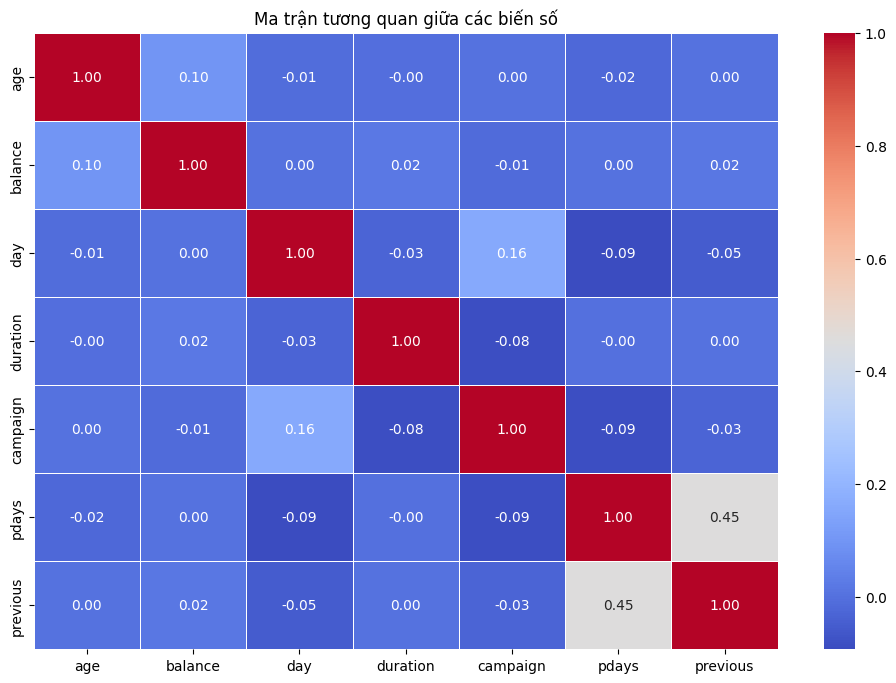

In [40]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

# có thể thấy ở đây pdays và previous có tương quan cao nhất (~0,45) -> có khả năng 2 biến này đi cùng nhau


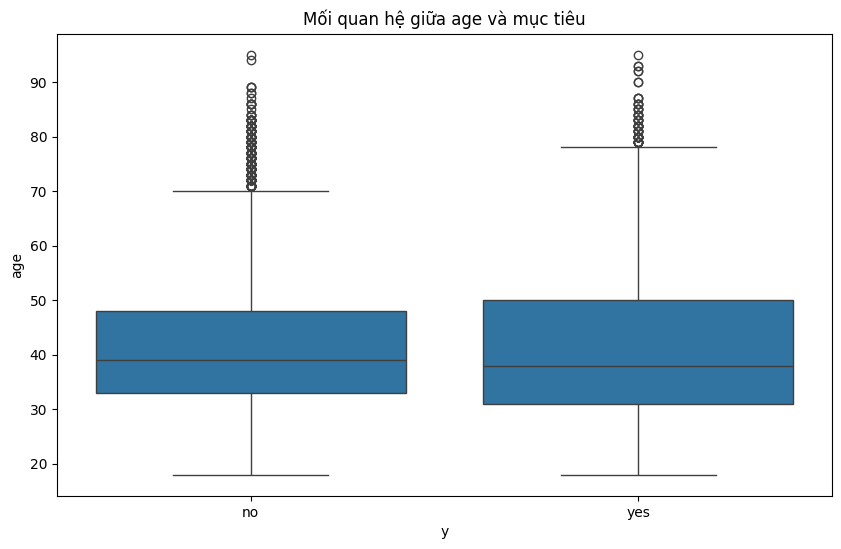

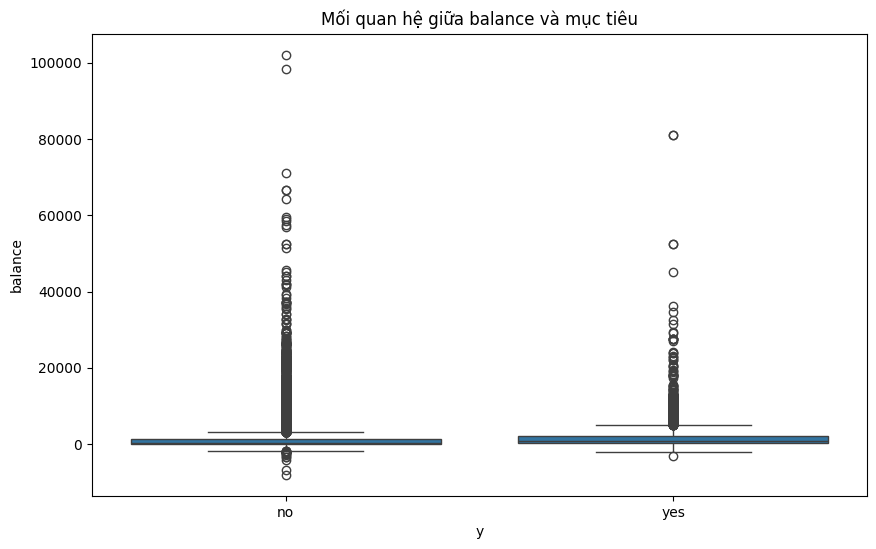

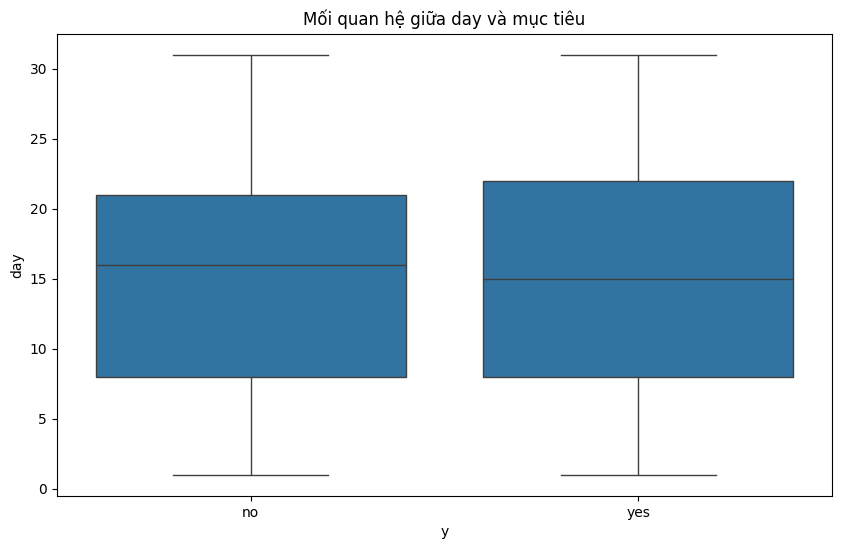

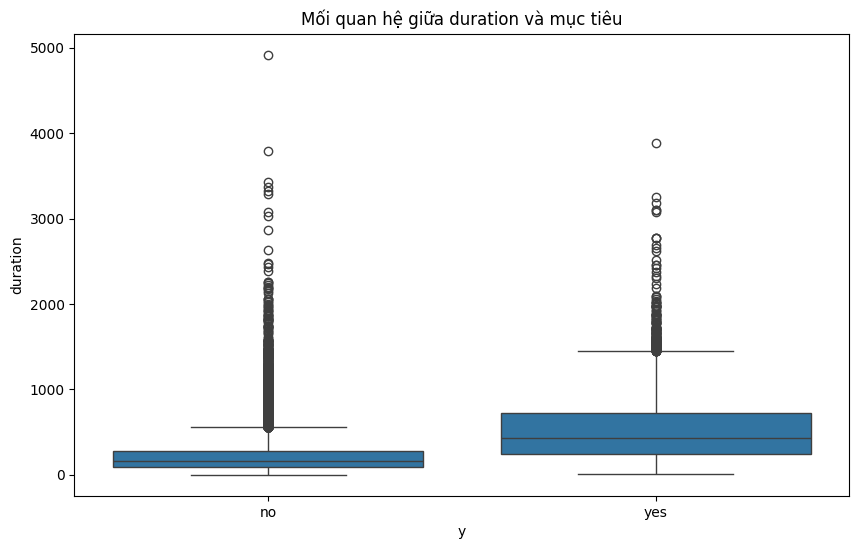

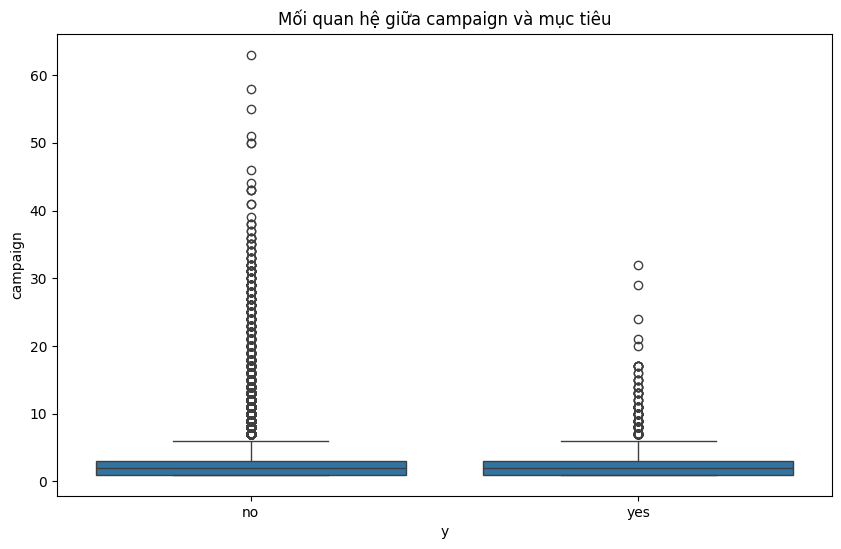

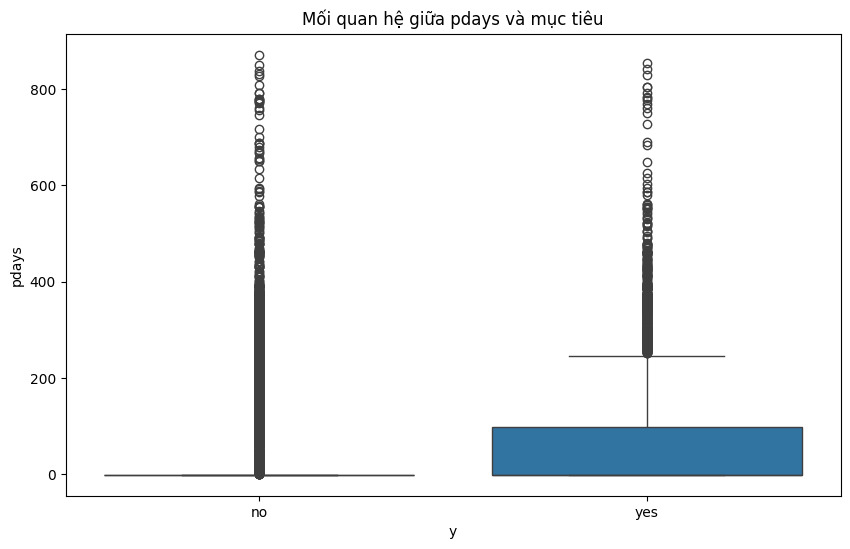

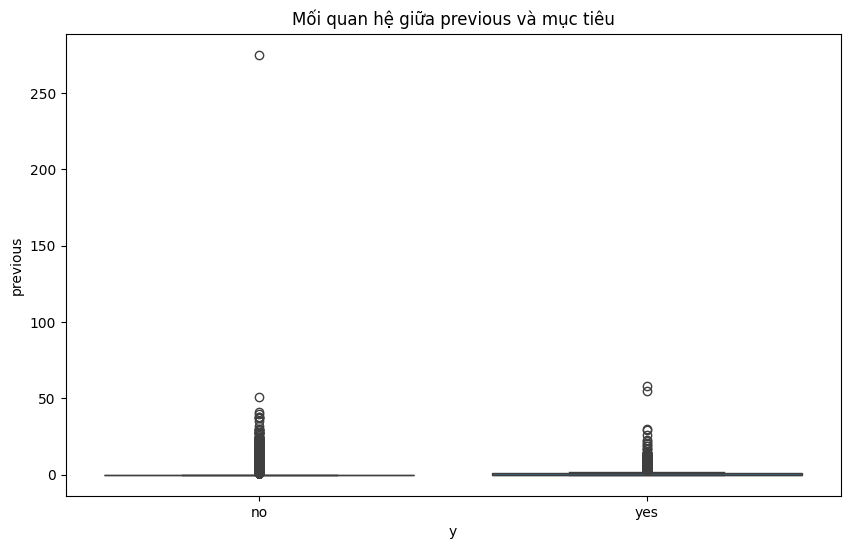

In [41]:
# Phân tích mối quan hệ giữa các biến số và biến mục tiêu
for col in numeric_cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'Mối quan hệ giữa {col} và mục tiêu')
    plt.show()

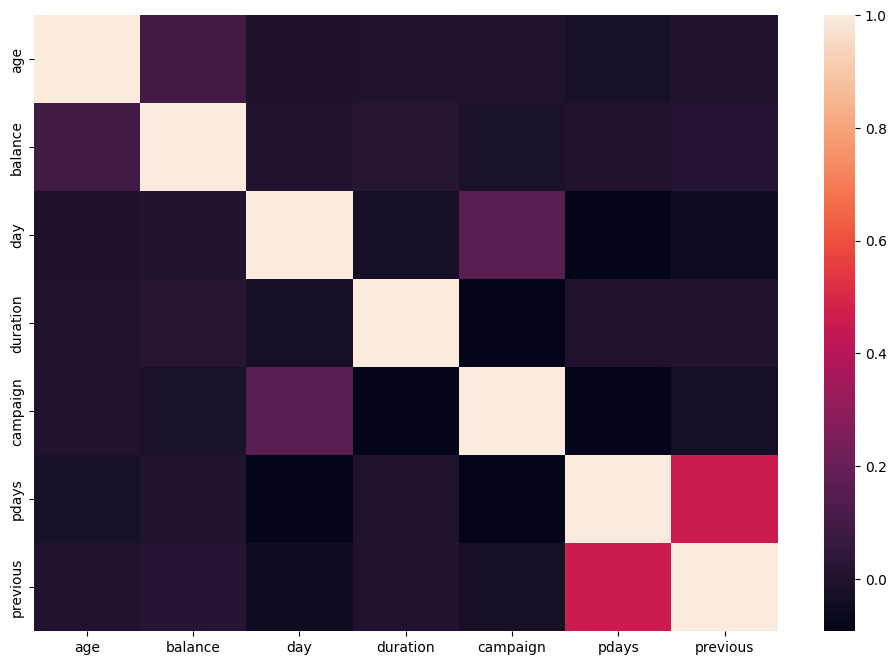

In [42]:
# numeric_cols = df.select_dtypes(include=np.number).columns
# corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True))
plt.show()

# 4. Data Splitting
**Nhiệm vụ:** Tách dataset thành 2 tập `X` (features) và `y` (target). Sau đó dùng `train_test_split` để chia thành tập Train và tập Test (ví dụ 80/20).


# 5. Model Training
**Nhiệm vụ:** Import các mô hình từ thư mục `src/` (Decision Tree, Random Forest). Huấn luyện các mô hình này trên tập Train.


# 6. Model Evaluation
**Nhiệm vụ:** Dự đoán trên tập Test và sử dụng thư viện metrics (Accuracy, F1-Score, Confusion Matrix) để đánh giá. Xem xét mô hình nào cho kết quả tốt hơn với lớp thiểu số (Yes).


### 2.5. Phân tích Đa biến (Bivariate Analysis)
Khám phá mối quan hệ giữa các đặc trưng (features) quan trọng và biến mục tiêu `y`.


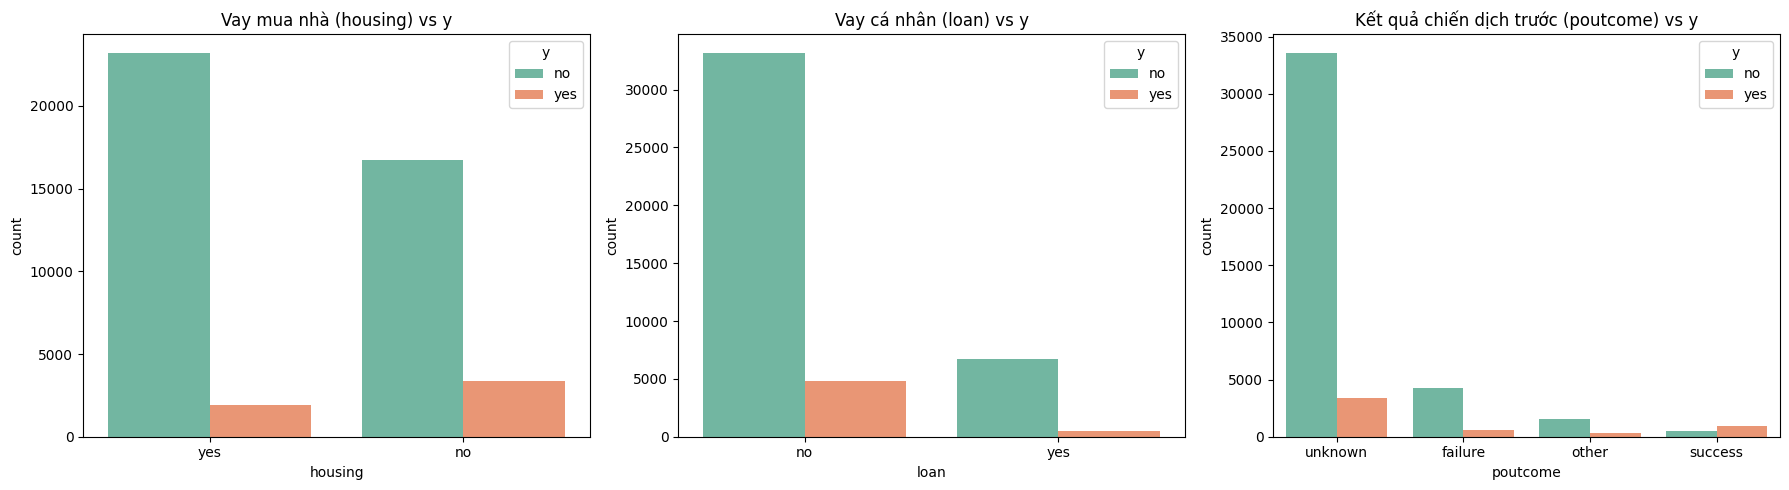

In [43]:
# 1. Nhóm biến phân loại (Categorical) ảnh hưởng tới y
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='housing', hue='y', ax=axes[0], palette='Set2')
axes[0].set_title('Vay mua nhà (housing) vs y')

sns.countplot(data=df, x='loan', hue='y', ax=axes[1], palette='Set2')
axes[1].set_title('Vay cá nhân (loan) vs y')

sns.countplot(data=df, x='poutcome', hue='y', ax=axes[2], palette='Set2')
axes[2].set_title('Kết quả chiến dịch trước (poutcome) vs y')

plt.tight_layout()
plt.show()


C:\Users\Bui Trong Nguyen\AppData\Local\Temp\ipykernel_21180\2180770636.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='duration', ax=axes[0], palette='Set2')
C:\Users\Bui Trong Nguyen\AppData\Local\Temp\ipykernel_21180\2180770636.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='balance', ax=axes[1], palette='Set2')


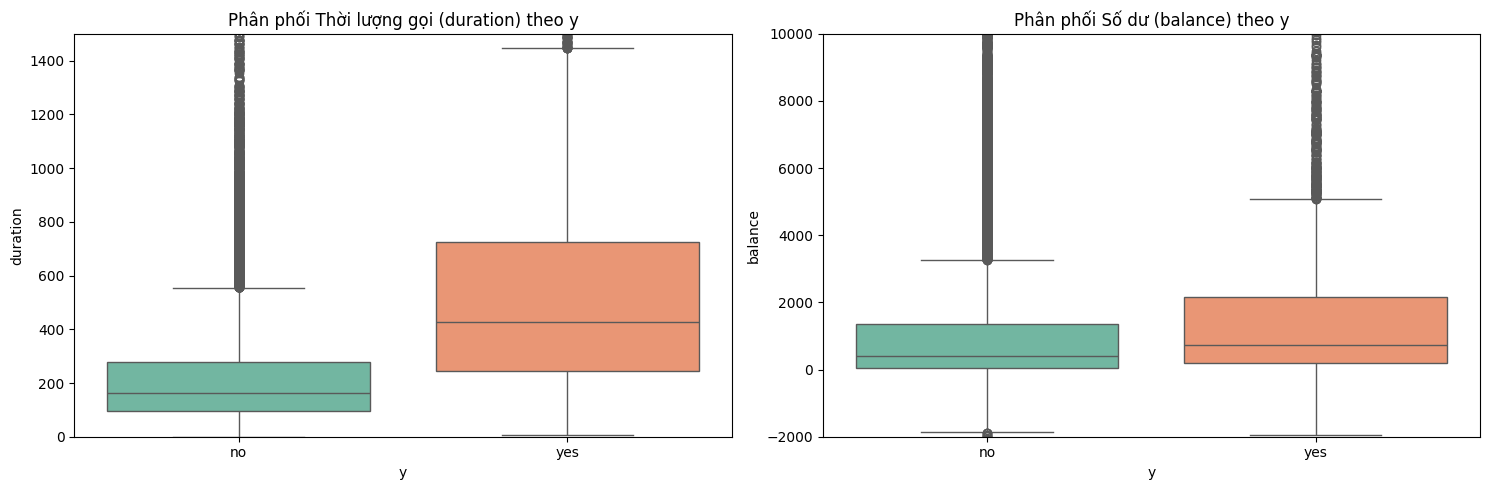

In [44]:
# 2. Nhóm biến số (Numerical) ảnh hưởng tới y
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Duration vs y
sns.boxplot(data=df, x='y', y='duration', ax=axes[0], palette='Set2')
axes[0].set_title('Phân phối Thời lượng gọi (duration) theo y')
axes[0].set_ylim(0, 1500) # Giới hạn trục y để cắt outlier giúp biểu đồ dễ nhìn hơn

# Balance vs y
sns.boxplot(data=df, x='y', y='balance', ax=axes[1], palette='Set2')
axes[1].set_title('Phân phối Số dư (balance) theo y')
axes[1].set_ylim(-2000, 10000)

plt.tight_layout()
plt.show()


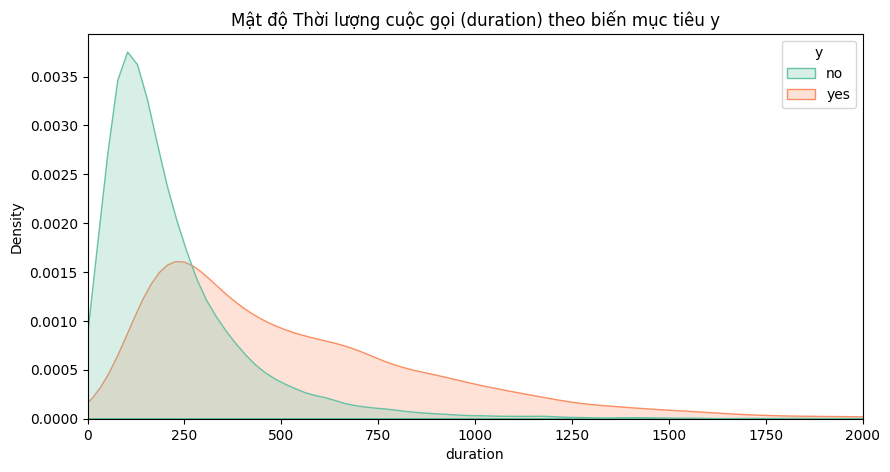

In [45]:
# Kdeplot cho Duration (thời lượng gọi) để trực quan mật độ phân phối
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='duration', hue='y', fill=True, common_norm=False, palette='Set2')
plt.title('Mật độ Thời lượng cuộc gọi (duration) theo biến mục tiêu y')
plt.xlim(0, 2000)
plt.show()


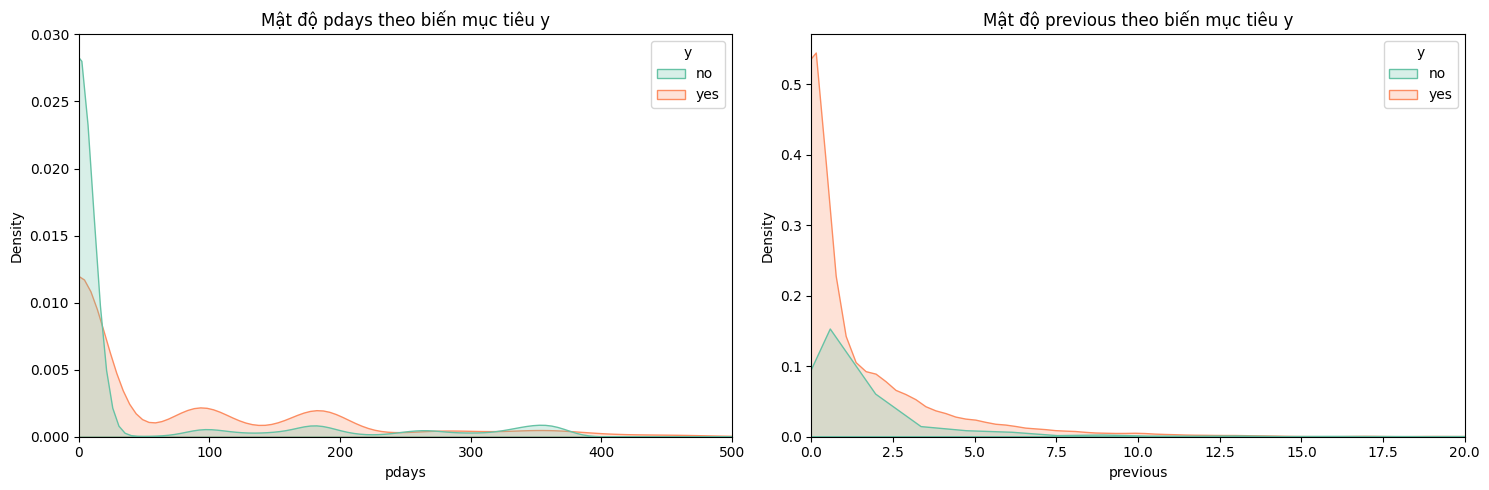

In [46]:
# Kdeplot cho pdays và previous
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df, x='pdays', hue='y', fill=True, common_norm=False, palette='Set2', ax=axes[0])
axes[0].set_title('Mật độ pdays theo biến mục tiêu y')
axes[0].set_xlim(0, 500)

sns.kdeplot(data=df, x='previous', hue='y', fill=True, common_norm=False, palette='Set2', ax=axes[1])
axes[1].set_title('Mật độ previous theo biến mục tiêu y')
axes[1].set_xlim(0, 20)

plt.tight_layout()
plt.show()


# 3. Feature Engineering
Tiến hành làm sạch, biến đổi dữ liệu định tính thành định lượng và tạo đặc trưng mới sẵn sàng cho mô hình.


### 3.1. Feature Transformer (Biến đổi dữ liệu)
**3.1.1. Xử lý giá trị khuyết thiếu (Missing Value Imputation)**
- `poutcome` (81% missing) và `contact` (28% missing): Điền bằng giá trị "unknown" vì đây là một lựa chọn hợp lệ trong thực tế.
- `education` và `job` (missing rất ít): Điền bằng giá trị xuất hiện nhiều nhất (mode).


In [47]:
df.isna().mean()

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64

In [48]:
df['pdays_cat'] = df['pdays'].apply(lambda x: 'No' if x == -1 else 'Yes')
df['pdays_cat']

0         No
1         No
2         No
3         No
4         No
        ... 
45206     No
45207     No
45208    Yes
45209     No
45210    Yes
Name: pdays_cat, Length: 45211, dtype: object

<Axes: xlabel='pdays_cat', ylabel='count'>

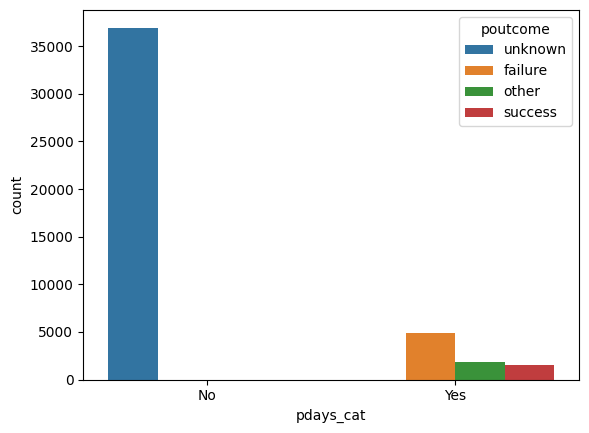

In [49]:
sns.countplot(x='pdays_cat', hue='poutcome', data=df)

<Axes: xlabel='job', ylabel='count'>

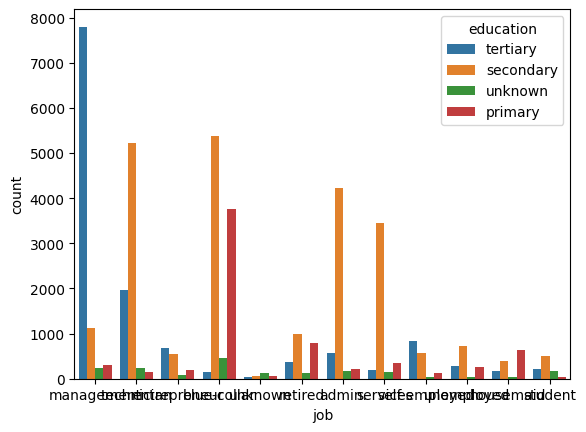

In [50]:
sns.countplot(x='job', hue='education', data=df)

In [51]:
# Fill missing values
df['poutcome'] = df['poutcome'].fillna('unknown')
## Poutcome true
df['contact'] = df['contact'].fillna('unknown')

df['education'] = df['education'].fillna(df['education'].mode()[0])
df['job'] = df['job'].fillna(df['job'].mode()[0])

print("Tổng số missing values hiện tại:", df.isna().sum().sum())


Tổng số missing values hiện tại: 0


**3.1.2. Xử lý ngoại lai (Outlier Handling)**
Các biến như `balance`, `duration`, `campaign` có chứa nhiều ngoại lai lớn. Ta sẽ dùng phương pháp **IQR Capping** để giới hạn giá trị lại. Không áp dụng cho `pdays` hay `previous` vì phân phối của chúng quá đặc thù (hầu hết bằng 0 hoặc -1).


In [52]:
# Capping bằng khoảng IQR
num_cols_with_outliers = ['balance', 'duration', 'campaign']
for col in num_cols_with_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Đã xử lý ngoại lai xong cho:", num_cols_with_outliers)


Đã xử lý ngoại lai xong cho: ['balance', 'duration', 'campaign']


### 3.2. Tạo đặc trưng mới (Feature Construction)
Từ logic và kiến thức nghiệp vụ, ta tạo thêm các biến để nhấn mạnh một sự kiện cụ thể có thể liên quan tới biến mục tiêu `y`.


In [53]:
# is_previously_contacted: Khách hàng có từng được liên hệ trong đợt chiến dịch trước hay không (yes/no)
# pdays > 0 nghĩa là đã từng liên hệ (pdays=-1 nghĩa là chưa từng)
df['is_previously_contacted'] = (df['pdays'] > 0).astype(int)

# has_negative_balance: Khách hàng đang có số dư âm (tệ hơn là số dư = 0)
df['has_negative_balance'] = (df['balance'] < 0).astype(int)

df[['pdays', 'is_previously_contacted', 'balance', 'has_negative_balance']].head()


,pdays,is_previously_contacted,balance,has_negative_balance
0,-1,0,2143,0
1,-1,0,29,0
2,-1,0,2,0
3,-1,0,1506,0
4,-1,0,1,0


**3.1.3. Mã hoá biến phân loại (Handling Categorical Features)**
- Các biến binary (`yes`/`no`): Chuyển thành `1`/`0`.
- Biến có thứ tự (`education`): Ordinal Encoding.
- Các biến đa hạng mục khác (`job`, `marital`, `contact`, `month`, `poutcome`): One-Hot Encoding (Tạo Dummy Variables).


In [54]:
import pandas as pd

# Binary Encoding cho biến Y/N
binary_cols = ['default', 'housing', 'loan', 'y']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Ordinal Encoding cho biến trình độ học vấn (education)
edu_mapping = {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
if df['education'].dtype == 'object':
    df['education'] = df['education'].map(edu_mapping)

# One-hot Encoding
nominal_cols = ['job', 'marital', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Kích thước dữ liệu sau khi mã hoá:", df.shape)


Kích thước dữ liệu sau khi mã hoá: (45211, 44)


In [55]:
df

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,3,0,2143,1,0,5,261,1,-1,...,False,False,False,True,False,False,False,False,False,True
1,44,2,0,29,1,0,5,151,1,-1,...,False,False,False,True,False,False,False,False,False,True
2,33,2,0,2,1,1,5,76,1,-1,...,False,False,False,True,False,False,False,False,False,True
3,47,0,0,1506,1,0,5,92,1,-1,...,False,False,False,True,False,False,False,False,False,True
4,33,0,0,1,0,0,5,198,1,-1,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0,825,0,0,17,643,3,-1,...,False,False,False,False,True,False,False,False,False,True
45207,71,1,0,1729,0,0,17,456,2,-1,...,False,False,False,False,True,False,False,False,False,True
45208,72,2,0,3462,0,0,17,643,5,184,...,False,False,False,False,True,False,False,False,True,False
45209,57,2,0,668,0,0,17,508,4,-1,...,False,False,False,False,True,False,False,False,False,True


**3.1.4. Chuẩn hoá dữ liệu (Feature Scaling)**
Đưa các biến số (numeric) về cùng một thang đo với mean=0 và std=1 bằng Standard Scaler để giảỉ quyết sai biệt độ lớn giữa các trường như `balance` và `age` hay `campaign`.


In [56]:
from sklearn.preprocessing import StandardScaler

numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

df[numerical_features].head()


,age,balance,day,duration,campaign,pdays,previous
0,1.606965,1.027653,-1.298476,0.147445,-0.870092,-0.411453,-0.25194
1,0.288529,-0.768817,-1.298476,-0.474910,-0.870092,-0.411453,-0.25194
2,-0.747384,-0.791761,-1.298476,-0.899243,-0.870092,-0.411453,-0.25194
3,0.571051,0.486333,-1.298476,-0.808718,-0.870092,-0.411453,-0.25194
4,-0.747384,-0.792611,-1.298476,-0.208994,-0.870092,-0.411453,-0.25194


### 3.3. Trích xuất đặc trưng (Feature Extraction)
*Lưu ý:* Đối với dữ liệu dạng bảng biểu phân tích hành vi con người, việc trích xuất đặc trưng hay giảm chiều (ví dụ: PCA, t-SNE) sẽ làm mất tính diễn giải của các đối tượng gốc (không còn rõ là age hay balance nữa). Nên ở bài toán Phân loại khách hàng Bank Marketing, ta **sẽ bỏ qua Feature Extraction** và đi thẳng tới Feature Selection để giữ tính diễn giải (Interpretability).


### 3.4. Lựa chọn đặc trưng (Feature Selection)
Sử dụng mô hình **Random Forest Classifier** để đánh giá "Mức độ quan trọng" (Feature Importance) của hơn 40 biến tạo ra từ One-Hot Encoding, qua đó rút gọn các đặc trưng mạnh nhất cho mô hình gốc.


In [57]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Tách biến Explainatory (X) và biến mục tiêu (y)
X = df.drop('y', axis=1)
y = df['y']

# Train Random Forest để lấy ra các features tốt nhất
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_k = 20
top_features = [X.columns[i] for i in indices][:top_k]

# Trực quan hoá Top 20 Features
plt.figure(figsize=(12, 6))
plt.title(f"Top {top_k} Đặc trưng quan trọng nhất (Random Forest Feature Importance)")
plt.bar(range(top_k), importances[indices][:top_k], align="center", color='#4287f5')
plt.xticks(range(top_k), top_features, rotation=45, ha='right')
plt.xlim([-1, top_k])
plt.tight_layout()
plt.show()

# Gán lại tập dữ liệu X với các top features
X_final = X[top_features]
print("Tập dữ liệu sau cùng (Features Set) sẵn sàng để Training có shape là:", X_final.shape)


ValueError: could not convert string to float: 'No'

# 4. Modeling (Huấn luyện Mô hình)
Chia dữ liệu, xây dựng mô hình Decision Tree và Đánh giá hiệu suất.


### 4.1. Chia tập dữ liệu (Train - Test Split)
Sử dụng tỷ lệ 80% train, 20% test. Sử dụng tham số `stratify=y` để đảm bảo tỷ lệ lớp mục tiêu ở tập train và test vẫn được giữ cân bằng như tập dữ liệu gốc.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")


Kích thước tập Train: (36168, 20)
Kích thước tập Test: (9043, 20)


### 4.2. Huấn luyện Mô hình Cây Quyết Định (Decision Tree Classifier)
Sử dụng DecisionTreeClassifier mặc định của thư viện scikit-learn. Đặt `max_depth` hợp lý hoặc dùng tham số `class_weight="balanced"` để khắc phục vấn đề Imbalanced data.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình Decision Tree, dùng class_weight='balanced' do dữ liệu mất cân bằng
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced', max_depth=10)
# Huấn luyện mô hình
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Dự đoán trên tập train và tập test
# y_train_pred = dt_model.predict(X_train)
# y_test_pred = dt_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

y_train_pred


array([0, 1, 1, ..., 0, 0, 1])

### 4.3. Đánh giá Mô hình (Validation)
Sử dụng 4 loại metric quan trọng cho bài toán phân loại: Accuracy, Precision, Recall, và F1-Score. Bên cạnh đó, hiển thị thêm Classification Report và Confusion Matrix.


--- Đánh giá trên tập Train ---
Accuracy : 0.8568
Precision: 0.4446
Recall   : 0.8988
F1-Score : 0.5950
--- Đánh giá trên tập Test ---
Accuracy : 0.8452
Precision: 0.4192
Recall   : 0.8384
F1-Score : 0.5589
Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7985
           1       0.42      0.84      0.56      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.84      0.73      9043
weighted avg       0.91      0.85      0.87      9043



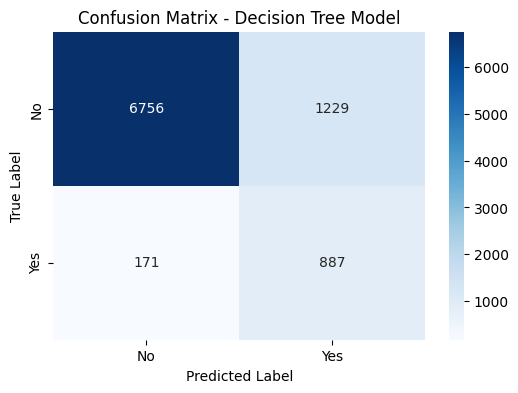

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hàm tính toán và in 4 loại metric
def evaluate_model(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- Đánh giá trên tập {dataset_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")

# In đánh giá
evaluate_model(y_train, y_train_pred, "Train")
evaluate_model(y_test, y_test_pred, "Test")

# In Classification Report chi tiết cho tập Test
print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Vẽ Confusion Matrix cho tập Test
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Model')
plt.show()


### 4.4. Nhận xét kết quả
- Với bài toán có dữ liệu mất cân bằng (Imbalanced), **Accuracy** không phải là thước đo đáng tin cậy nhất. 
- **Recall** (Độ nhạy): Rất quan trọng khi ta không muốn bỏ sót những khách hàng tiềm năng đồng ý mở sổ tiết kiệm. Mô hình có Recall trên tập nhóm Yes tốt chứng tỏ class_weight="balanced" đã phát huy tác dụng.
- **Precision** (Độ chính xác): Tỷ lệ những người dự đoán là Mở Sổ thực sự mở. Cần cân bằng bù trừ với Recall qua **F1-Score**.


### 4.5. Huấn luyện Mô hình Convolutional Neural Network (1D CNN)
Mặc dù CNN thường được dùng cho hình ảnh và chuỗi thời gian, ta vẫn có thể áp dụng **1D CNN** để khai thác các đặc trưng từ dữ liệu dạng bảng.
*Lưu ý: Bạn cần cài đặt thư viện tensorflow trước khi chạy cell này (`pip install tensorflow`)*.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import numpy as np

# Reshape dữ liệu về dạng 3D (samples, timesteps, features) để đưa vào 1D CNN
X_train_cnn = np.expand_dims(X_train.values, axis=2)
X_test_cnn = np.expand_dims(X_test.values, axis=2)

print("Kích thước X_train cho CNN:", X_train_cnn.shape)

# Xây dựng kiến trúc mô hình 1D CNN
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Phân loại nhị phân (Yes/No)
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình (sử dụng class_weight để xử lý mất cân bằng lớp tương tự như Decision Tree)
# Tính toán class_weight thủ công
neg, pos = np.bincount(y_train)
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

history = cnn_model.fit(
    X_train_cnn, y_train, 
    epochs=15, 
    batch_size=64, 
    validation_split=0.2, 
    class_weight=class_weight,
    verbose=1
)


Kích thước X_train cho CNN: (36168, 20, 1)


c:\Users\Bui Trong Nguyen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Invalid dtype: object

### 4.6. Đánh giá Mô hình 1D CNN
Áp dụng ngưỡng 0.5 để quy đổi xác suất dự đoán (ra từ hàm sigmoid) thành nhãn để so sánh.


In [ ]:
# Dự đoán xác suất
y_train_pred_prob = cnn_model.predict(X_train_cnn)
y_test_pred_prob = cnn_model.predict(X_test_cnn)

# Quy đổi xác suất thành nhãn (0, 1) với ngưỡng 0.5
y_train_pred_cnn = (y_train_pred_prob > 0.5).astype(int).flatten()
y_test_pred_cnn = (y_test_pred_prob > 0.5).astype(int).flatten()

# In đánh giá CNN
print("===== ĐÁNH GIÁ MÔ HÌNH 1D CNN =====")
evaluate_model(y_train, y_train_pred_cnn, "Train")
evaluate_model(y_test, y_test_pred_cnn, "Test")

# Confusion Matrix cho CNN
cm_cnn = confusion_matrix(y_test, y_test_pred_cnn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - 1D CNN Model')
plt.show()

# Nhận xét nhanh: 
# Thường đối với bài toán dạng bảng đơn thuần, mô hình Machine Learning như Decision Tree hay Random Forest, XGBoost hay cho kết quả vượt trội hơn so với CNN.
# Kết quả CNN ở đây có thể gặp hiện tượng thay đổi tuỳ vào cấu trúc và độ dày đặc của các layers.
